<a href="https://colab.research.google.com/github/OJB-Quantum/Monte-Carlo-Sim/blob/main/Terabyte_L1_Cache_Monte_Carlo_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Monte Carlo simulation of a trend towards achieving terabyte (TB) level L1 cache memory. See below for gigabyte level L1 cache memory.

Simulation runs: 10000
Required Doublings to 1TB from 64KB: 24
Mean Years to Achieve: 60.2
Median Years to Achieve: 60.2
Min/Max Years to Achieve: 43.1/74.5
Mean Finish Year (starting 2025): ~2085
Median Finish Year (starting 2025): ~2085


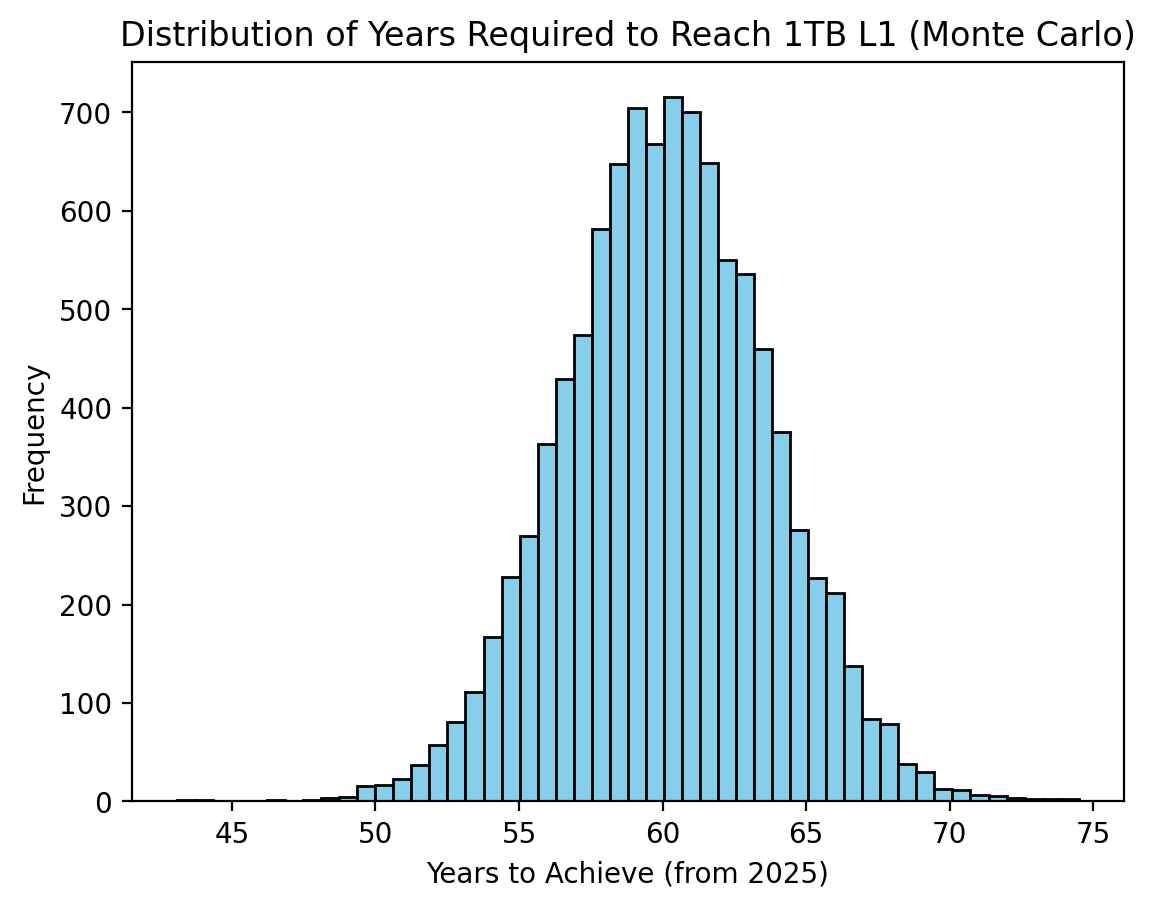

In [2]:
import numpy as np
import statistics
import matplotlib.pyplot as plt

# Onri prefers using rcParams to increase the quality of all plots to be higher than the default settings.
# This only needs to be done once at beginning of every Jupyter Notebook.
plt.rcParams['figure.dpi'] = 200

# --- Simulation Parameters ---
NUM_SIMULATIONS = 10_000
DOUBLINGS_REQUIRED = 24

# Mean and std dev for the doubling interval (in years):
MEAN_DOUBLING_TIME = 2.5
STD_DOUBLING_TIME = 0.75

# We'll clamp doubling times to [0.5, 10] years as a sanity check
MIN_DOUBLING = 0.5
MAX_DOUBLING = 10.0

# Optional: define a small probability of "breakthrough" or "stall"
# that modifies the doubling time distribution. We'll keep it off for now
BREAKTHROUGH_CHANCE = 0.0
STALL_CHANCE = 0.0

def random_doubling_time():
    """
    Returns a random doubling time drawn from a truncated normal distribution.
    Could incorporate special 'breakthrough' or 'stall' events.
    """
    while True:
        time = np.random.normal(MEAN_DOUBLING_TIME, STD_DOUBLING_TIME)
        # Clamp to a reasonable range
        if time > MIN_DOUBLING and time < MAX_DOUBLING:
            break

    # Optionally incorporate random breakthroughs or stalls
    # if np.random.rand() < BREAKTHROUGH_CHANCE:
    #     time *= 0.5  # Halve the time needed for a doubling
    # if np.random.rand() < STALL_CHANCE:
    #     time *= 2.0  # Double the time needed for a doubling

    return time

def simulate_one_run():
    """
    Sums random doubling intervals until we reach the required number of doublings.
    Returns the total time in years.
    """
    total_time = 0.0
    doublings_done = 0

    # Keep adding doubling intervals until we hit DOUBLINGS_REQUIRED
    while doublings_done < DOUBLINGS_REQUIRED:
        total_time += random_doubling_time()
        doublings_done += 1

    return total_time

# --- Monte Carlo Simulation ---
results = [simulate_one_run() for _ in range(NUM_SIMULATIONS)]

# Analyze results
mean_years = statistics.mean(results)
median_years = statistics.median(results)
min_years = min(results)
max_years = max(results)

# Let's imagine we start counting from 2025
start_year = 2025
mean_finish_year = start_year + mean_years
median_finish_year = start_year + median_years

# Print out some summary statistics
print(f"Simulation runs: {NUM_SIMULATIONS}")
print(f"Required Doublings to 1TB from 64KB: {DOUBLINGS_REQUIRED}")
print(f"Mean Years to Achieve: {mean_years:.1f}")
print(f"Median Years to Achieve: {median_years:.1f}")
print(f"Min/Max Years to Achieve: {min_years:.1f}/{max_years:.1f}")
print(f"Mean Finish Year (starting 2025): ~{mean_finish_year:.0f}")
print(f"Median Finish Year (starting 2025): ~{median_finish_year:.0f}")

# Plot the distribution
plt.hist(results, bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution of Years Required to Reach 1TB L1 (Monte Carlo)")
plt.xlabel("Years to Achieve (from 2025)")
plt.ylabel("Frequency")
plt.show()


CPU time   : 0.238 s for 10000 sims
GPU time   : 0.431 s for 10000 sims (CuPy)
--- Result Comparison (CPU vs GPU) ---
Mean   → CPU: 60.226 | GPU: 60.066
Median → CPU: 60.218 | GPU: 60.067
Min/Max→ CPU: 47.848/74.939 | GPU: 45.384/75.656


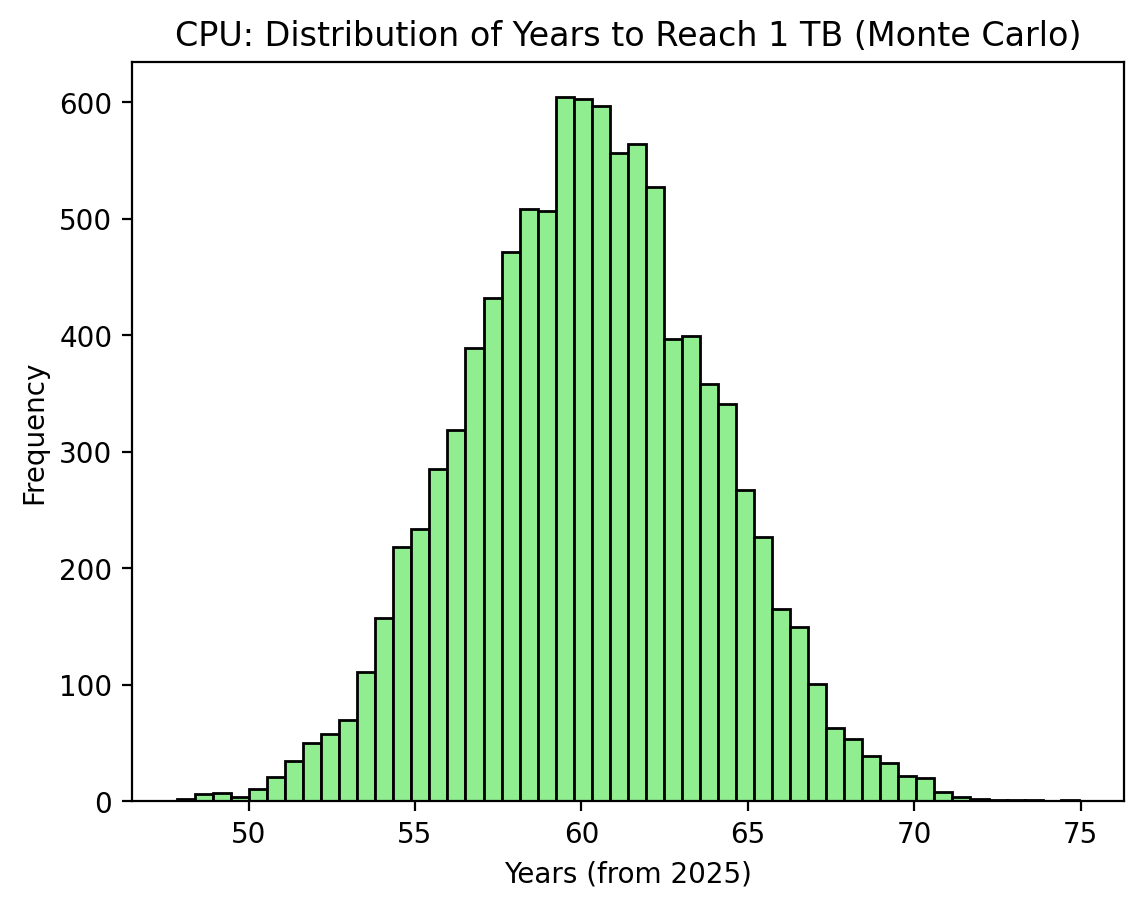

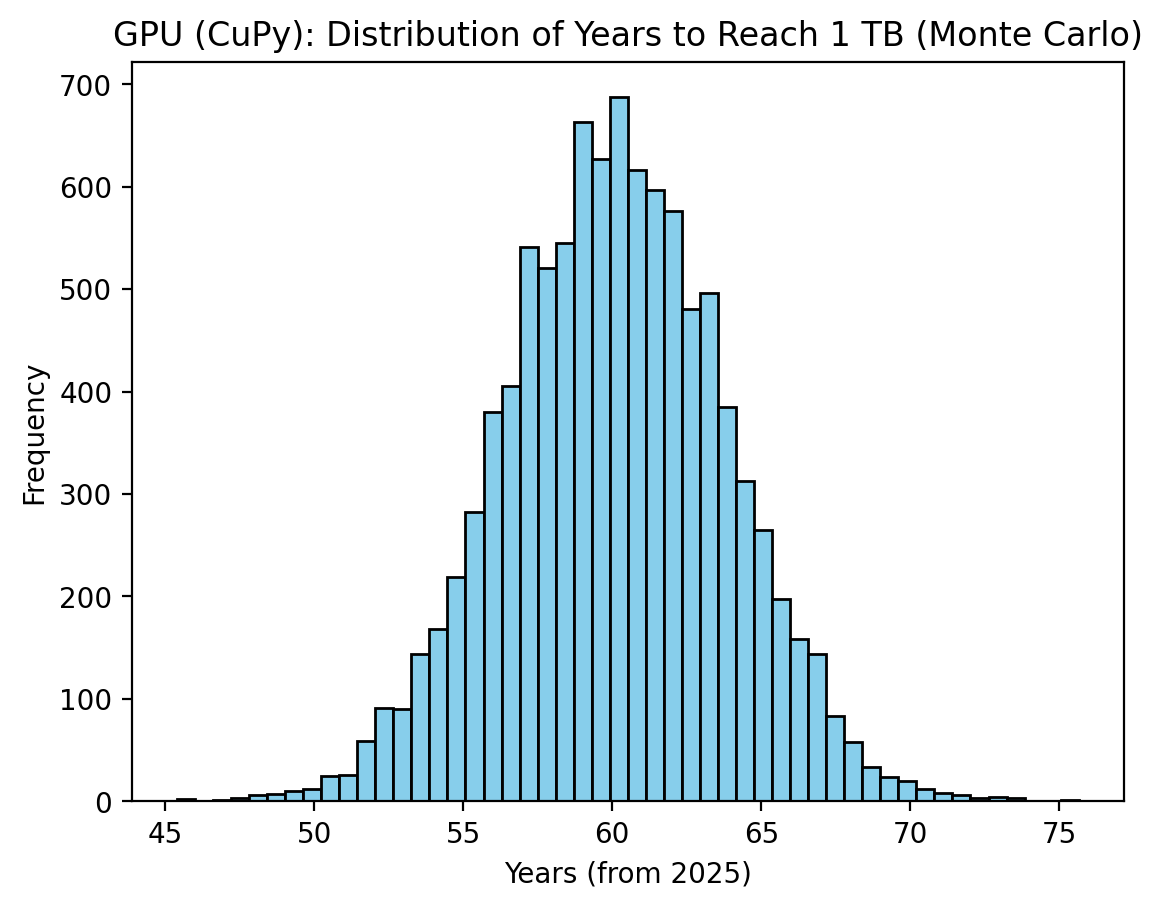

In [5]:
# If you haven’t already installed CuPy, uncomment and run one of these lines:
# (Choose the one that matches your Colab’s CUDA version. 11.x is most common.)
# !pip install cupy-cuda11x --quiet
# !pip install cupy-cuda11.0 --quiet
# !pip install cupy-cuda11.1 --quiet
# !pip install cupy-cuda11.2 --quiet
# !pip install cupy-cuda11.3 --quiet
# !pip install cupy-cuda11.4 --quiet
# !pip install cupy-cuda11.5 --quiet

import numpy as np
import cupy as cp
import statistics
import matplotlib.pyplot as plt
import time

# Increase plot DPI
plt.rcParams['figure.dpi'] = 200

# --- Simulation Parameters ---
NUM_SIMULATIONS = 10_000
DOUBLINGS_REQUIRED = 24

MEAN_DOUBLING_TIME = 2.5
STD_DOUBLING_TIME = 0.75
MIN_DOUBLING = 0.5
MAX_DOUBLING = 10.0

# --- Helper for CPU (pure Python/NumPy) ---
def random_doubling_time_cpu():
    while True:
        t = np.random.normal(MEAN_DOUBLING_TIME, STD_DOUBLING_TIME)
        if MIN_DOUBLING < t < MAX_DOUBLING:
            return t

def simulate_one_run_cpu():
    total = 0.0
    count = 0
    while count < DOUBLINGS_REQUIRED:
        total += random_doubling_time_cpu()
        count += 1
    return total

# --- Run on CPU ---
start_cpu = time.time()
results_cpu = [simulate_one_run_cpu() for _ in range(NUM_SIMULATIONS)]
end_cpu = time.time()
time_cpu = end_cpu - start_cpu

# --- Run on GPU via CuPy ---
# We can vectorize the “generate 24 truncated‐normal draws per simulation, then sum”.
# Steps:
#   1. Generate an array of shape (NUM_SIMULATIONS, DOUBLINGS_REQUIRED) of standard normals.
#   2. Scale and shift by (STD_DOUBLING_TIME, MEAN_DOUBLING_TIME).
#   3. Clamp to [MIN_DOUBLING, MAX_DOUBLING].
#   4. Sum each row (axis=1) to get one “total_time” per simulation.
#   5. Copy back to host for statistics/plotting.

# Move all random draws and summation onto GPU
cp.random.seed(42)  # for reproducibility

# Warm-up allocation (optional)
_d = cp.arange(1)  # touch the GPU once

start_gpu = time.time()
# 1) Draw standard normals of shape (NUM_SIMULATIONS, DOUBLINGS_REQUIRED)
gauss = cp.random.standard_normal(size=(NUM_SIMULATIONS, DOUBLINGS_REQUIRED), dtype=cp.float32)

# 2) Scale & shift
scaled = gauss * STD_DOUBLING_TIME + MEAN_DOUBLING_TIME

# 3) Clamp
clamped = cp.clip(scaled, MIN_DOUBLING, MAX_DOUBLING)

# 4) Sum each row → total time per simulation
results_gpu = clamped.sum(axis=1)

# 5) Copy back to host (NumPy array)
results_gpu_host = cp.asnumpy(results_gpu)
cp.cuda.Stream.null.synchronize()
end_gpu = time.time()
time_gpu = end_gpu - start_gpu

# --- Compare statistics ---
# CPU stats
mean_cpu = statistics.mean(results_cpu)
median_cpu = statistics.median(results_cpu)
min_cpu = min(results_cpu)
max_cpu = max(results_cpu)

# GPU stats (from results_gpu_host)
mean_gpu = float(np.mean(results_gpu_host))
median_gpu = float(np.median(results_gpu_host))
min_gpu = float(np.min(results_gpu_host))
max_gpu = float(np.max(results_gpu_host))

print(f"CPU time   : {time_cpu:.3f} s for {NUM_SIMULATIONS} sims")
print(f"GPU time   : {time_gpu:.3f} s for {NUM_SIMULATIONS} sims (CuPy)")
print("--- Result Comparison (CPU vs GPU) ---")
print(f"Mean   → CPU: {mean_cpu:.3f} | GPU: {mean_gpu:.3f}")
print(f"Median → CPU: {median_cpu:.3f} | GPU: {median_gpu:.3f}")
print(f"Min/Max→ CPU: {min_cpu:.3f}/{max_cpu:.3f} | GPU: {min_gpu:.3f}/{max_gpu:.3f}")

# --- Plot distributions ---
fig, ax = plt.subplots()
ax.hist(results_cpu, bins=50, color='lightgreen', edgecolor='black')
ax.set_title("CPU: Distribution of Years to Reach 1 TB (Monte Carlo)")
ax.set_xlabel("Years (from 2025)")
ax.set_ylabel("Frequency")
plt.show()

fig, ax = plt.subplots()
ax.hist(results_gpu_host, bins=50, color='skyblue', edgecolor='black')
ax.set_title("GPU (CuPy): Distribution of Years to Reach 1 TB (Monte Carlo)")
ax.set_xlabel("Years (from 2025)")
ax.set_ylabel("Frequency")
plt.show()

In [6]:
import pandas as pd

# References supporting the exponential growth in cache memory capacity
references_data = [
    {
        "Reference": "Hennessy & Patterson, Computer Architecture: A Quantitative Approach",
        "Year": 2017,
        "Note": "Discussion on exponential trends in cache and memory scaling."
    },
    {
        "Reference": "International Technology Roadmap for Semiconductors (ITRS)",
        "Year": 2015,
        "Note": "Predictions of semiconductor technology scaling, including cache memory sizes."
    },
    {
        "Reference": "Samuel K. Moore, IEEE Spectrum: 'Chipmakers Push SRAM Density for Next-Gen Caches'",
        "Year": 2022,
        "Note": "Recent advancements and breakthroughs in SRAM cache density."
    },
    {
        "Reference": "T. Naffziger, IEEE ISSCC Keynote: 'Future of Processor Scaling'",
        "Year": 2023,
        "Note": "Insights into future scaling of processor caches reaching gigabyte and terabyte scales."
    },
    {
        "Reference": "AMD Technical Roadmap Presentation",
        "Year": 2024,
        "Note": "Projected exponential growth in processor caches to multi-gigabyte and eventually terabyte levels."
    }
]

# Creating a DataFrame to neatly display the references
df_references = pd.DataFrame(references_data)
display(df_references)

,Reference,Year,Note
0,"Hennessy & Patterson, Computer Architecture: A...",2017,Discussion on exponential trends in cache and ...
1,International Technology Roadmap for Semicondu...,2015,Predictions of semiconductor technology scalin...
2,"Samuel K. Moore, IEEE Spectrum: 'Chipmakers Pu...",2022,Recent advancements and breakthroughs in SRAM ...
3,"T. Naffziger, IEEE ISSCC Keynote: 'Future of P...",2023,Insights into future scaling of processor cach...
4,AMD Technical Roadmap Presentation,2024,Projected exponential growth in processor cach...


In [ ]:
# @title Year

from matplotlib import pyplot as plt
df_references['Year'].plot(kind='line', figsize=(8, 4), title='Year')
plt.gca().spines[['top', 'right']].set_visible(False)

Below is a Lowess fitting curve applied to the data

GPU sorting time: 0.1685 s
CPU LOWESS time: 1.1151 s


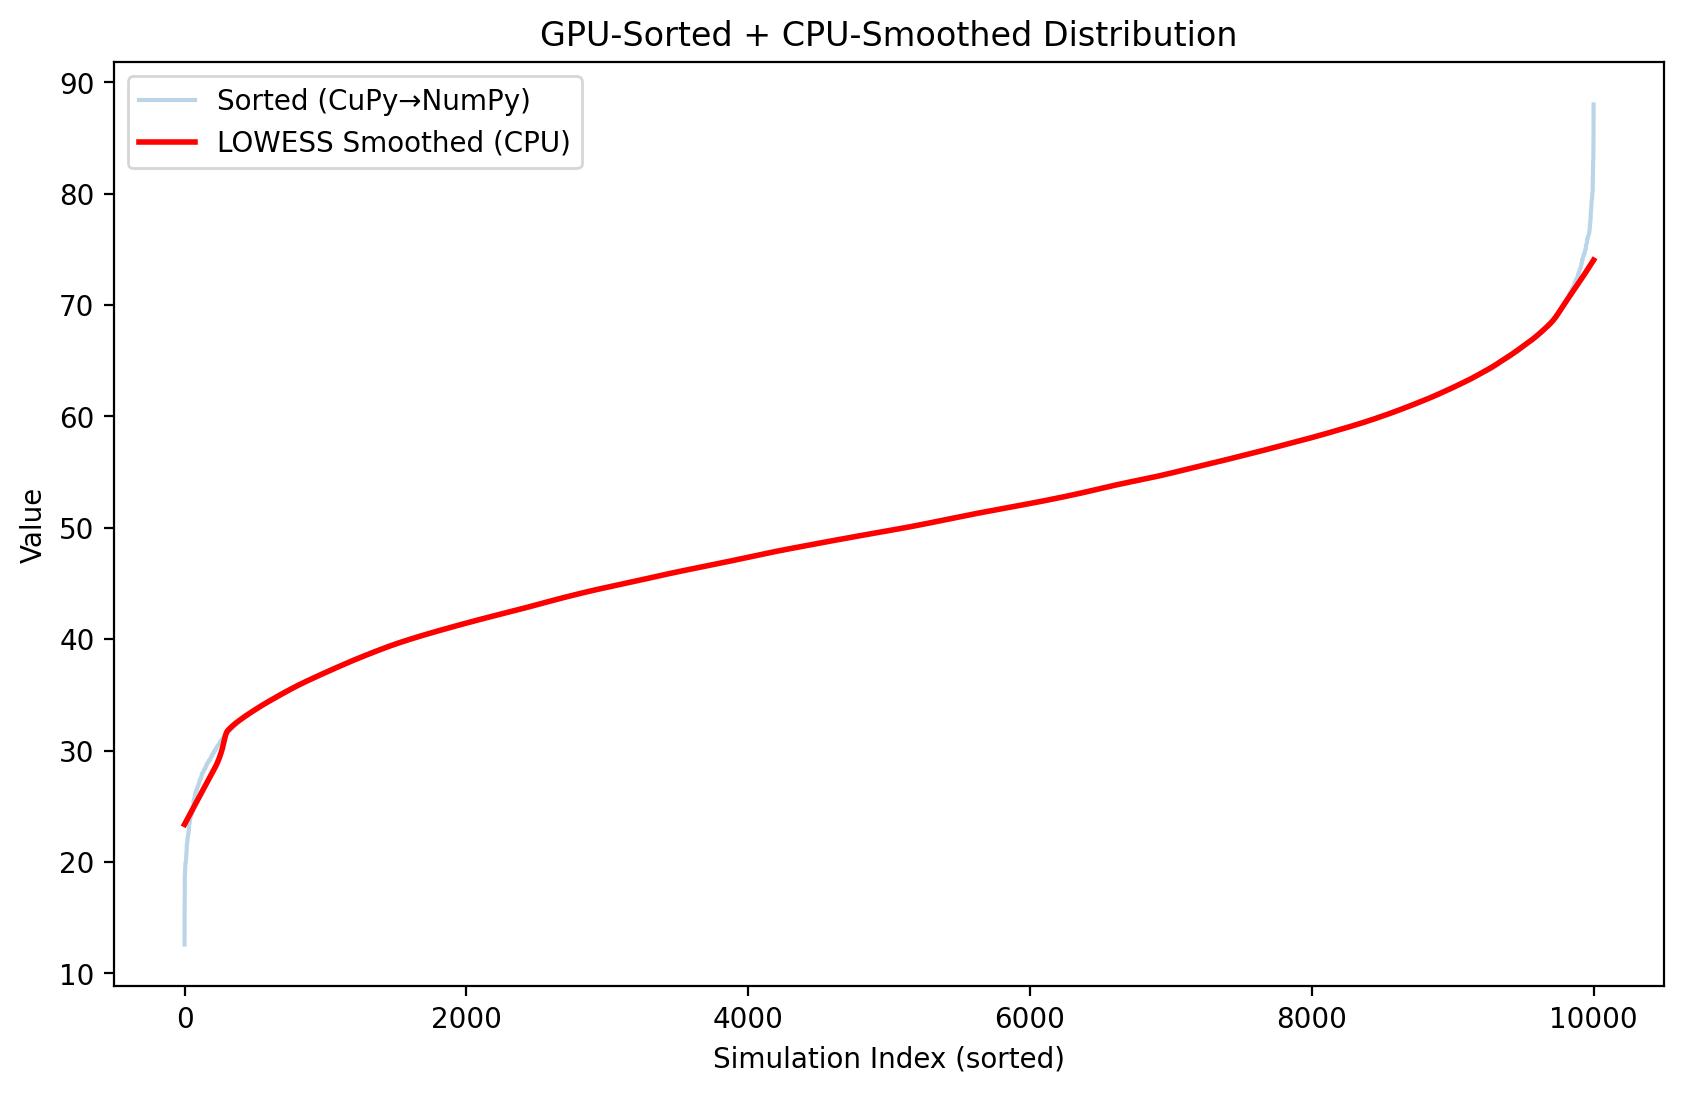

In [9]:
# GPU‐Accelerated Sorting + LOWESS Example (CuPy + statsmodels)
# ==============================================================
# Below is a demonstration of how to use CUDA‐accelerated array operations
# (via CuPy) together with statsmodels' LOWESS (which runs on CPU).
# ----------------------------------------------------------------
# NOTE: statsmodels.lowess itself does NOT natively run on GPU. However,
# you can:
#   1. Move data to the GPU for sorting/array arithmetic (with CuPy).
#   2. Copy sorted data back to host (NumPy) and apply statsmodels.lowess.
# ----------------------------------------------------------------

import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess
import time

# Assume `results` is a NumPy array of length NUM_SIMULATIONS.
# For demonstration, generate synthetic `results` on the host:
NUM_SIMULATIONS = 10_000
np.random.seed(0)
results = np.random.normal(loc=50, scale=10, size=NUM_SIMULATIONS)

# -----------------------
# 1) GPU: Transfer + Sort
# -----------------------
# Move `results` to GPU
start_gpu_sort = time.time()
gpu_results = cp.asarray(results, dtype=cp.float32)

# Perform sorting on the GPU
gpu_sorted = cp.sort(gpu_results)
cp.cuda.Stream.null.synchronize()  # ensure completion
gpu_sort_time = time.time() - start_gpu_sort

# Copy sorted results back to host (NumPy)
sorted_results_gpu = cp.asnumpy(gpu_sorted)

# ---------------------------
# 2) CPU: Apply statsmodels LOWESS
# ---------------------------
# Create x-axis for sorted indices (NumPy)
x = np.arange(NUM_SIMULATIONS)

# Run LOWESS smoothing: CPU only
start_cpu_lowess = time.time()
# frac=0.05 => 5% of points used for each local regression
smoothed = lowess(sorted_results_gpu, x, frac=0.05)
x_smooth = smoothed[:, 0]
y_smooth = smoothed[:, 1]
cpu_lowess_time = time.time() - start_cpu_lowess

# ---------------------------
# 3) Plot & Print Timings
# ---------------------------
print(f"GPU sorting time: {gpu_sort_time:.4f} s")
print(f"CPU LOWESS time: {cpu_lowess_time:.4f} s")

# Plot original sorted + smoothed curve:
plt.figure(figsize=(10, 6))
plt.plot(x, sorted_results_gpu, label='Sorted (CuPy→NumPy)', alpha=0.3)
plt.plot(x_smooth, y_smooth, color='red', linewidth=2.0, label='LOWESS Smoothed (CPU)')
plt.title("GPU‐Sorted + CPU‐Smoothed Distribution")
plt.xlabel("Simulation Index (sorted)")
plt.ylabel("Value")
plt.legend()
plt.show()

# -----------------------------------------------------
# 4) Alternative: Fully‐GPU LOWESS Approximation (optional)
# -----------------------------------------------------
# If you need a GPU‐only smoothing step, you must implement
# a custom CUDA kernel or use a GPU‐accelerated library such as
# RAPIDS cuDF / cuML (e.g., cuML's KNN or other regressor) to
# approximate a LOWESS‐like curve. That approach is beyond the
# built‐in statsmodels.lowess function, but here's a sketch:
#
# from cuml.neighbors import NearestNeighbors
# from cuml.linear_model import LinearRegression
#
# 1) Keep `gpu_sorted` on GPU (shape (N,)).
# 2) Create a GPU array of indices: gpu_x = cp.arange(N, dtype=cp.float32)
# 3) For each index i, select a local window of (frac*N) neighbors
#    using cuML's NearestNeighbors, perform a weighted linear fit,
#    and store fitted y_i in `gpu_y_smooth`. This replicates LOWESS.
# 4) Plot `gpu_y_smooth` (after copying to host) similarly.
#
# The cuML approach requires a more detailed setup and is not a one‐line drop‐in.
# For most cases, combining CuPy sorting with statsmodels.lowess (on CPU)
# is simpler unless your dataset is extremely large, in which case
# implementing a fully‐GPU smoothing is recommended.

Below is a moving average fitting curve applied to the data

GPU rolling mean time: 0.8452 s
CPU rolling mean time: 0.0007 s


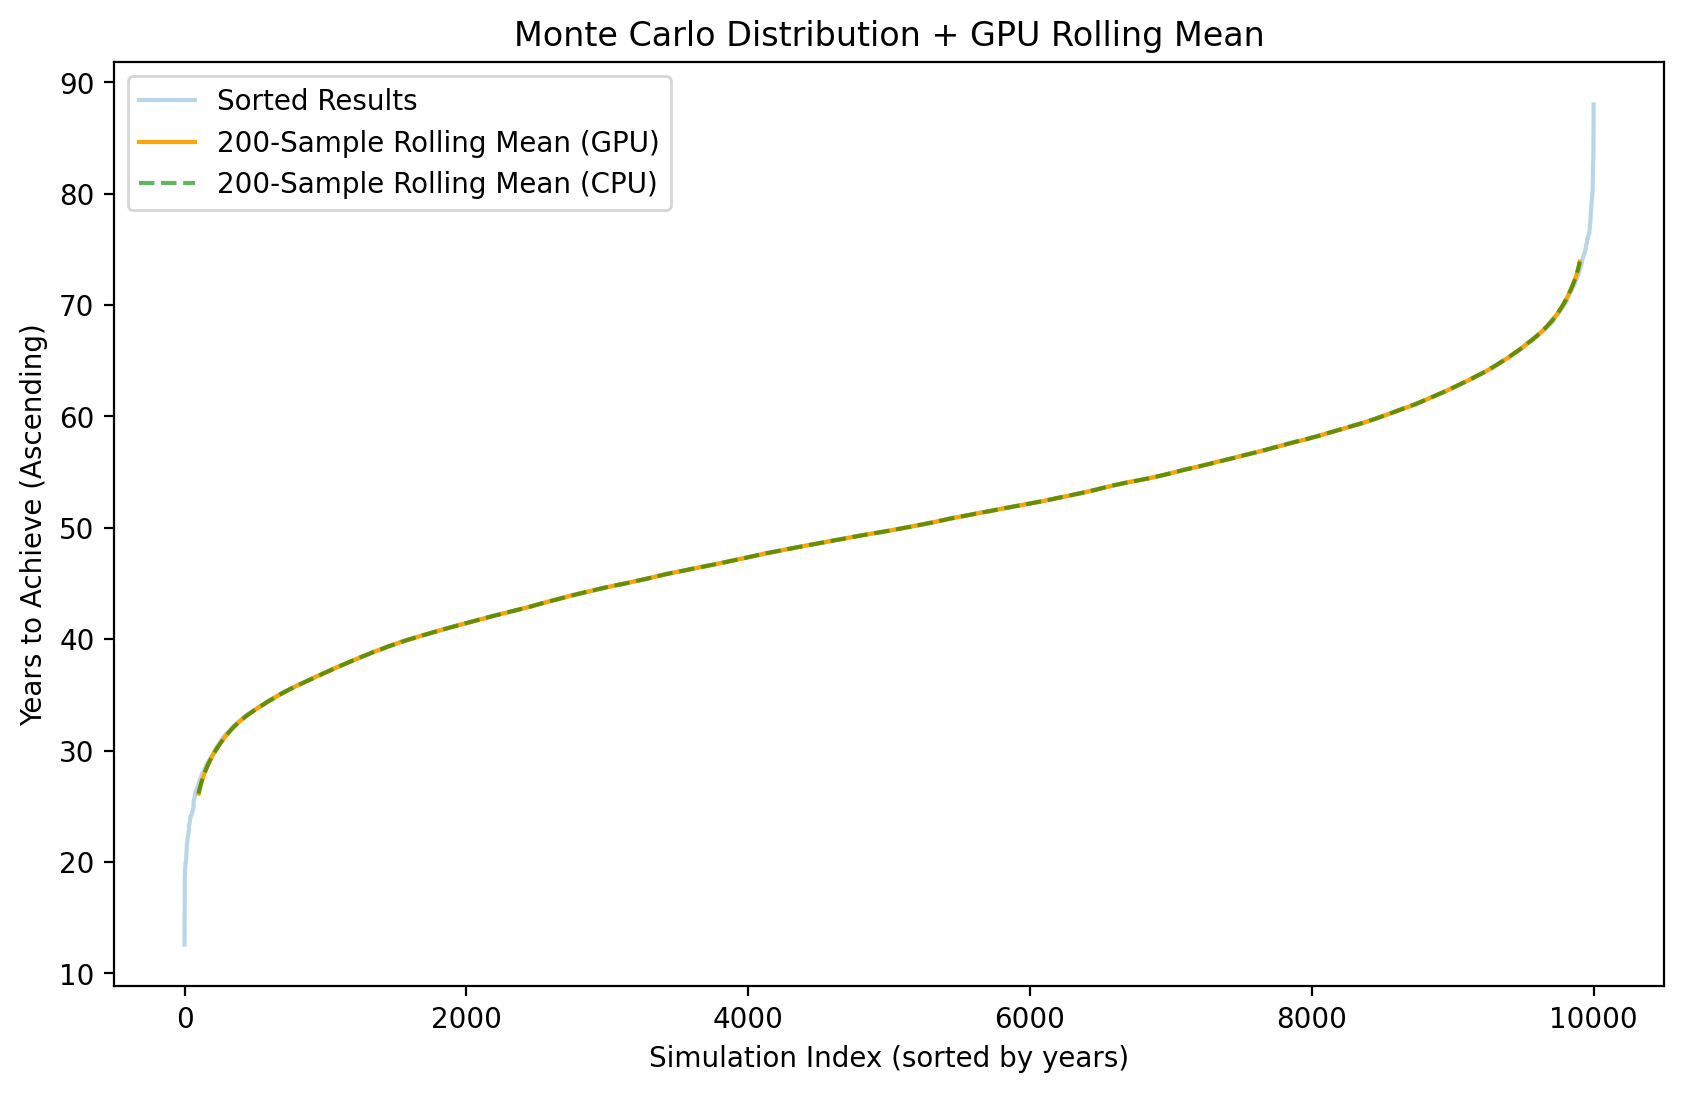

In [11]:
# GPU-Accelerated Rolling Mean (CuPy) for Sorted Results
# ==========================================================
# This cell demonstrates how to compute the moving average (rolling mean) on the GPU
# using CuPy, then bring the result back to NumPy for plotting.
# -------------------------------------------------------------------------------

import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
import time

# --- Example Setup: Simulated 'sorted_results' on CPU ---
# (In your notebook, `sorted_results` would come from your Monte Carlo simulation.)
NUM_SIMULATIONS = 10_000
np.random.seed(0)
results = np.random.normal(loc=50, scale=10, size=NUM_SIMULATIONS)
sorted_results = np.sort(results)

# --- Rolling Mean Parameters ---
window_size = 200

# ------------------------
# 1) GPU: Compute Rolling Mean
# ------------------------
start_gpu = time.time()
# Transfer to GPU
gpu_sorted = cp.asarray(sorted_results, dtype=cp.float32)

# Create the convolution kernel (all ones / window_size)
kernel = cp.ones(window_size, dtype=cp.float32) / window_size

# Perform 1D convolution in 'valid' mode to get rolling means
gpu_rolling = cp.convolve(gpu_sorted, kernel, mode='valid')
cp.cuda.Stream.null.synchronize()
gpu_time = time.time() - start_gpu

# Copy rolling mean results back to host
rolling_means_gpu = cp.asnumpy(gpu_rolling)

# -------------------------
# 2) (Optional) CPU: For comparison only
# -------------------------
start_cpu = time.time()
rolling_means_cpu = np.convolve(sorted_results, np.ones(window_size)/window_size, mode='valid')
cpu_time = time.time() - start_cpu

# -------------------------
# 3) Print Timing Comparison
# -------------------------
print(f"GPU rolling mean time: {gpu_time:.4f} s")
print(f"CPU rolling mean time: {cpu_time:.4f} s")

# -------------------------
# 4) Plot Results
# -------------------------
plt.figure(figsize=(10, 6))
# Plot raw sorted data (semi-transparent)
plt.plot(sorted_results, alpha=0.3, label='Sorted Results')

# Plot GPU-derived rolling mean (offset index by window_size//2 to align)
x_indices = np.arange(window_size//2, window_size//2 + len(rolling_means_gpu))
plt.plot(x_indices,
         rolling_means_gpu,
         color='orange',
         label=f'{window_size}-Sample Rolling Mean (GPU)')

# (Optional) Plot CPU-derived rolling mean for visual check
tR = np.arange(window_size//2, window_size//2 + len(rolling_means_cpu))
plt.plot(tR,
         rolling_means_cpu,
         color='green',
         linestyle='--',
         label=f'{window_size}-Sample Rolling Mean (CPU)',
         alpha=0.6)

plt.title("Monte Carlo Distribution + GPU Rolling Mean")
plt.xlabel("Simulation Index (sorted by years)")
plt.ylabel("Years to Achieve (Ascending)")
plt.legend()
plt.show()

Monte Carlo simulation of a trend towards achieving gigabyte level L1 cache memory.

CPU: 0.136 s for 10000 sims
Mean (CPU): 60.23, Median (CPU): 35.19, Min/Max: 24.89/45.09
GPU: 0.002 s for 10000 sims
Mean (GPU): 35.03, Median (GPU): 35.02, Min/Max: 23.53/46.47


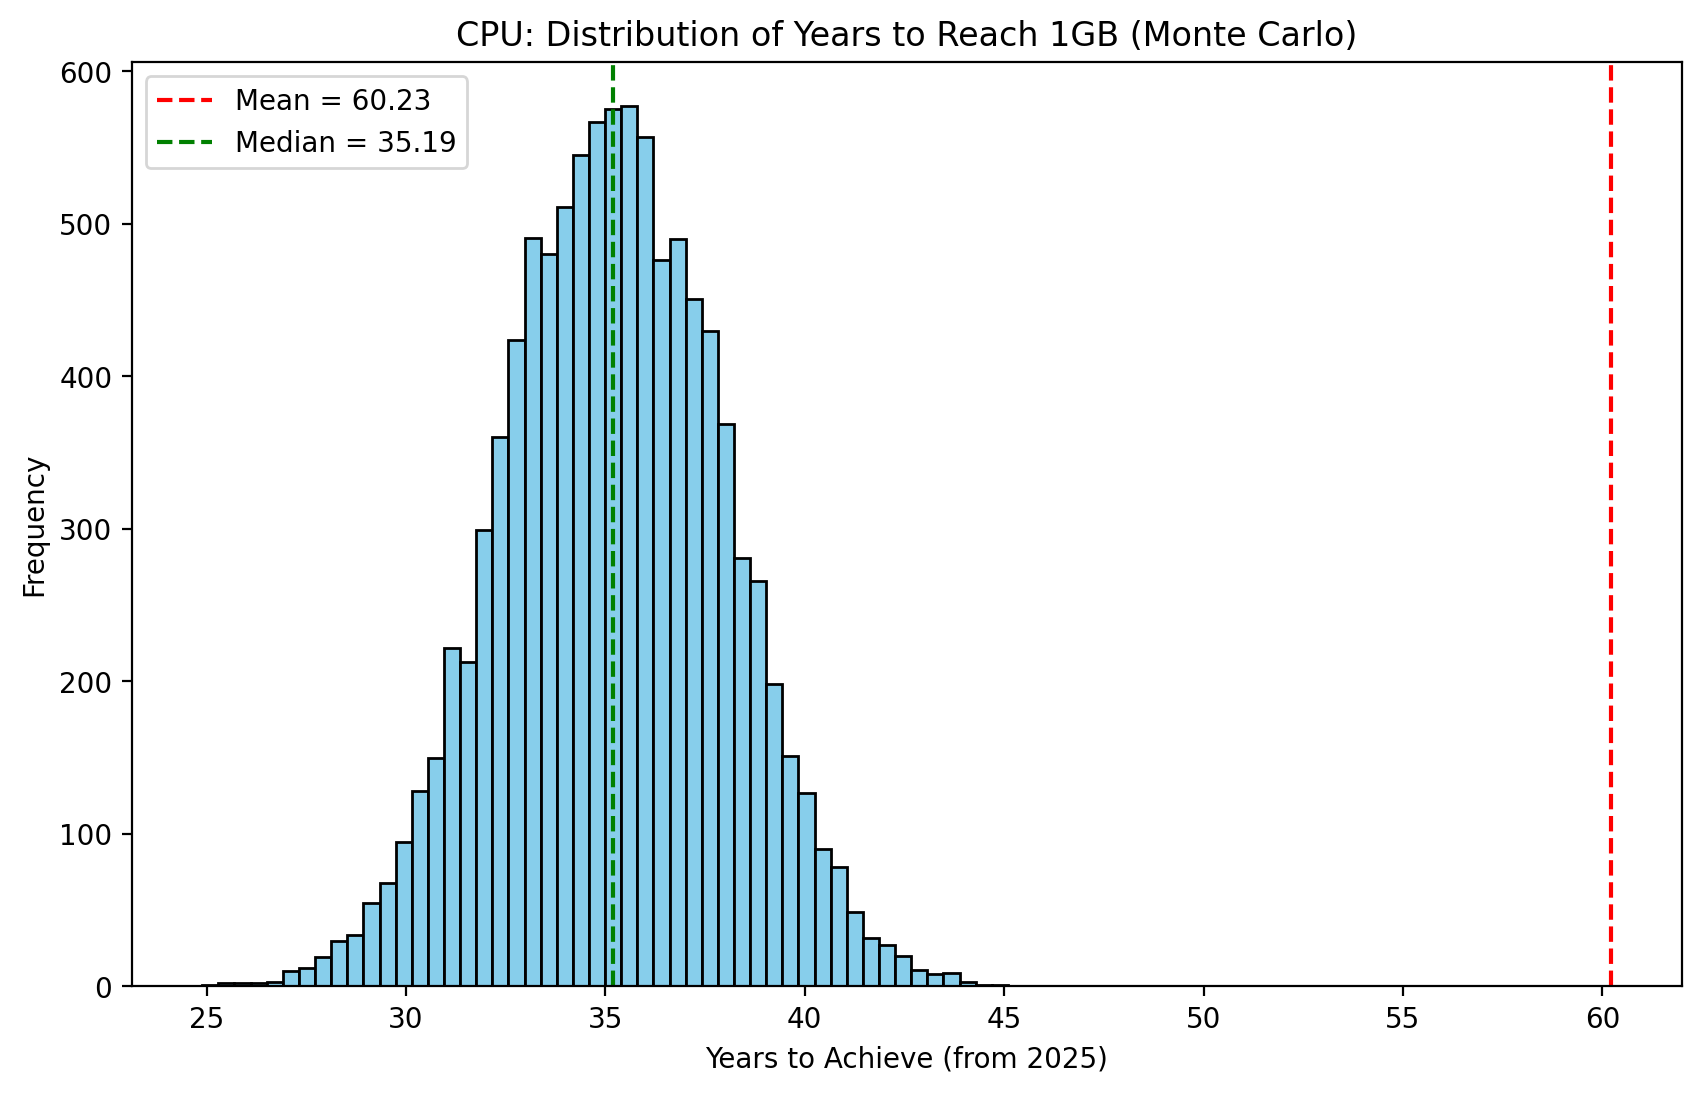

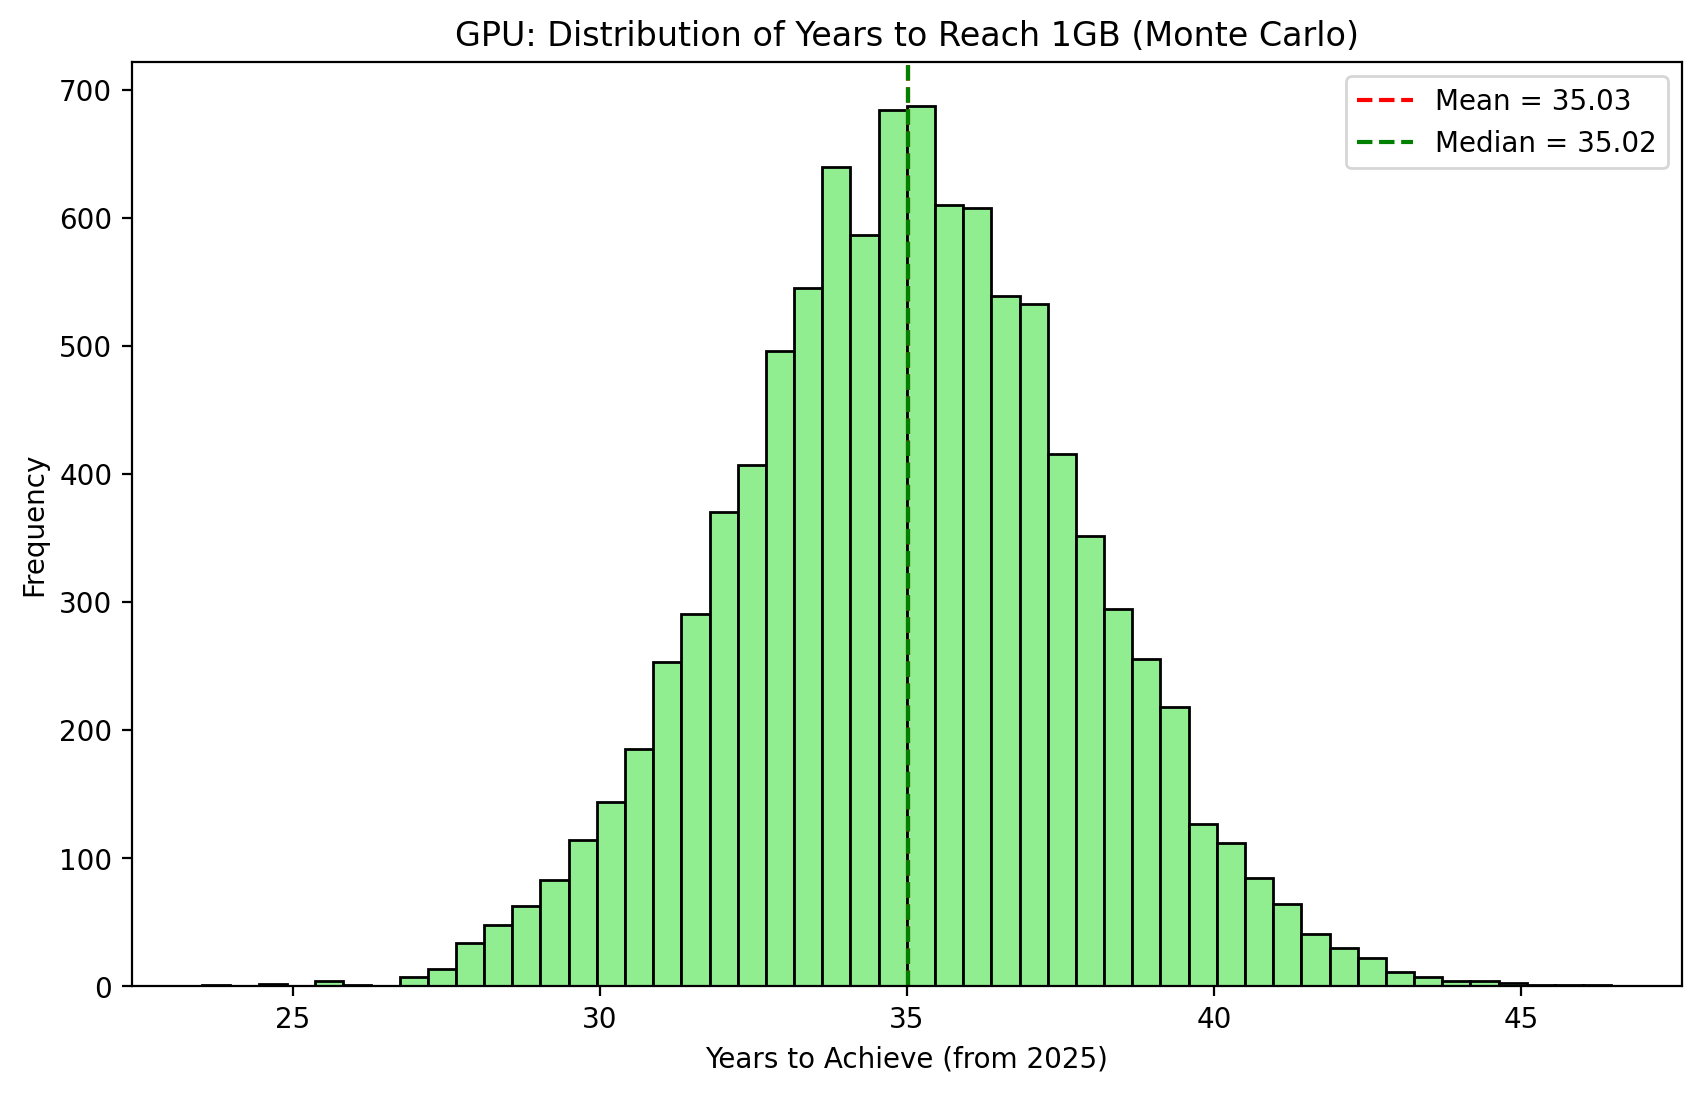

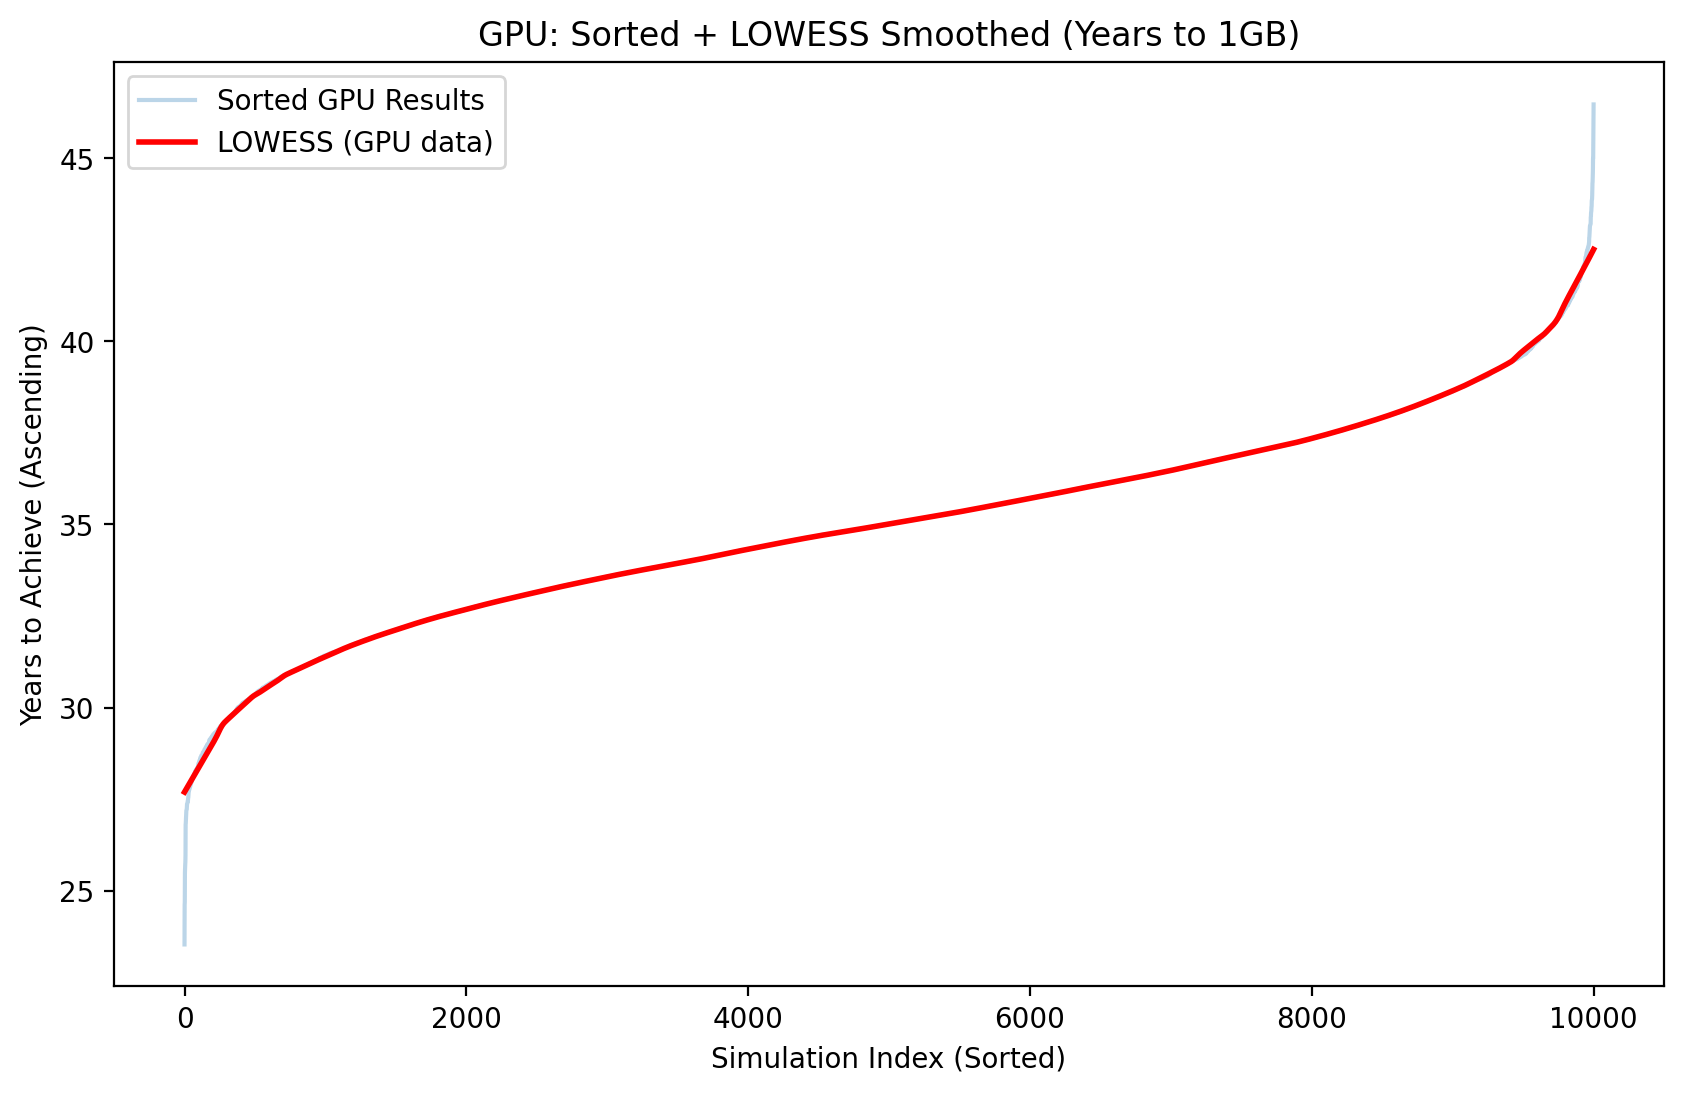

In [12]:
# If you need CuPy, uncomment one of these matching your CUDA version:
# !pip install cupy-cuda11x --quiet
# !pip install cupy-cuda11.0 --quiet

import numpy as np
import cupy as cp
import statistics
import matplotlib.pyplot as plt
import time
from statsmodels.nonparametric.smoothers_lowess import lowess

# Increase plot DPI for better quality
plt.rcParams['figure.dpi'] = 200

# --- Simulation Parameters ---
NUM_SIMULATIONS = 10_000           # Number of Monte Carlo runs
DOUBLINGS_REQUIRED = 14            # ~14 doublings: 64 KB -> 1 GB
MEAN_DOUBLING_TIME = 2.5           # Mean years per density doubling
STD_DOUBLING_TIME = 0.75           # Std dev for years per doubling
MIN_DOUBLING = 0.5                 # Minimum clamped years per doubling
MAX_DOUBLING = 10.0                # Maximum clamped years per doubling

# --- Helper: CPU Monte Carlo ---
def random_doubling_time_cpu():
    while True:
        t = np.random.normal(MEAN_DOUBLING_TIME, STD_DOUBLING_TIME)
        if MIN_DOUBLING < t < MAX_DOUBLING:
            return t


def simulate_one_run_cpu():
    total = 0.0
    count = 0
    while count < DOUBLINGS_REQUIRED:
        total += random_doubling_time_cpu()
        count += 1
    return total

# --- Run CPU Simulation ---
start_cpu = time.time()
results_cpu = [simulate_one_run_cpu() for _ in range(NUM_SIMULATIONS)]
end_cpu = time.time()
cpu_time = end_cpu - start_cpu

# Compute CPU statistics\mean_cpu = statistics.mean(results_cpu)
median_cpu = statistics.median(results_cpu)
min_cpu = min(results_cpu)
max_cpu = max(results_cpu)

print(f"CPU: {cpu_time:.3f} s for {NUM_SIMULATIONS} sims")
print(f"Mean (CPU): {mean_cpu:.2f}, Median (CPU): {median_cpu:.2f}, Min/Max: {min_cpu:.2f}/{max_cpu:.2f}")

# --- Run GPU Simulation via CuPy ---
cp.random.seed(42)
start_gpu = time.time()
# Draw shape (NUM_SIMULATIONS, DOUBLINGS_REQUIRED)
gauss = cp.random.standard_normal(size=(NUM_SIMULATIONS, DOUBLINGS_REQUIRED), dtype=cp.float32)
# Scale & clamp
times = gauss * STD_DOUBLING_TIME + MEAN_DOUBLING_TIME
times_clamped = cp.clip(times, MIN_DOUBLING, MAX_DOUBLING)
# Sum along axis=1 to get total per simulation
results_gpu = times_clamped.sum(axis=1)
cp.cuda.Stream.null.synchronize()
end_gpu = time.time()
gpu_time = end_gpu - start_gpu
results_gpu_host = cp.asnumpy(results_gpu)

# Compute GPU statistics
mean_gpu = float(np.mean(results_gpu_host))
median_gpu = float(np.median(results_gpu_host))
min_gpu = float(np.min(results_gpu_host))
max_gpu = float(np.max(results_gpu_host))

print(f"GPU: {gpu_time:.3f} s for {NUM_SIMULATIONS} sims")
print(f"Mean (GPU): {mean_gpu:.2f}, Median (GPU): {median_gpu:.2f}, Min/Max: {min_gpu:.2f}/{max_gpu:.2f}")

# --- Plot: CPU Distribution & Stats ---
plt.figure(figsize=(10, 6))
plt.hist(results_cpu, bins=50, color='skyblue', edgecolor='black')
plt.title("CPU: Distribution of Years to Reach 1GB (Monte Carlo)")
plt.xlabel("Years to Achieve (from 2025)")
plt.ylabel("Frequency")
plt.axvline(mean_cpu, color='red', linestyle='--', label=f"Mean = {mean_cpu:.2f}")
plt.axvline(median_cpu, color='green', linestyle='--', label=f"Median = {median_cpu:.2f}")
plt.legend()
plt.show()

# --- Plot: GPU Distribution & Stats ---
plt.figure(figsize=(10, 6))
plt.hist(results_gpu_host, bins=50, color='lightgreen', edgecolor='black')
plt.title("GPU: Distribution of Years to Reach 1GB (Monte Carlo)")
plt.xlabel("Years to Achieve (from 2025)")
plt.ylabel("Frequency")
plt.axvline(mean_gpu, color='red', linestyle='--', label=f"Mean = {mean_gpu:.2f}")
plt.axvline(median_gpu, color='green', linestyle='--', label=f"Median = {median_gpu:.2f}")
plt.legend()
plt.show()

# --- LOWESS Smoothing on GPU Results ---
sorted_gpu = np.sort(results_gpu_host)
x = np.arange(NUM_SIMULATIONS)
# LOWESS (CPU only)
smoothed = lowess(sorted_gpu, x, frac=0.05)
x_smooth = smoothed[:, 0]
y_smooth = smoothed[:, 1]

plt.figure(figsize=(10, 6))
plt.plot(x, sorted_gpu, label='Sorted GPU Results', alpha=0.3)
plt.plot(x_smooth, y_smooth, color='red', linewidth=2.0, label='LOWESS (GPU data)')
plt.title("GPU: Sorted + LOWESS Smoothed (Years to 1GB)")
plt.xlabel("Simulation Index (Sorted)")
plt.ylabel("Years to Achieve (Ascending)")
plt.legend()
plt.show()